<a href="https://colab.research.google.com/github/SohelPharmacy/Chembl/blob/main/python/CDD_ML_Part_2_Sohel_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bioinformatics Project - Computational Drug Discovery [Part 2] Exploratory Data Analysis**

Chanin Nantasenamat

[*'Data Professor' YouTube channel*](http://youtube.com/dataprofessor)

In this Jupyter notebook, we will be building a real-life **data science project** that you can include in your **data science portfolio**. Particularly, we will be building a machine learning model using the ChEMBL bioactivity data.

In **Part 2**, we will be performing Descriptor Calculation and Exploratory Data Analysis.

---

## **Install conda and rdkit**

In [40]:
! wget https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
! chmod +x Miniconda3-py37_4.8.2-Linux-x86_64.sh
! bash ./Miniconda3-py37_4.8.2-Linux-x86_64.sh -b -f -p /usr/local
! conda install -c rdkit rdkit -y
import sys
sys.path.append('/usr/local/lib/python3.7/site-packages/')

--2025-12-23 19:55:34--  https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.191.158, 104.16.32.241, 2606:4700::6810:20f1, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.191.158|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 85055499 (81M) [application/x-sh]
Saving to: ‘Miniconda3-py37_4.8.2-Linux-x86_64.sh.1’

Miniconda3-py37_4.8 100%[===================>]  81.12M  93.0MB/s    in 0.9s    

2025-12-23 19:55:35 (93.0 MB/s) - ‘Miniconda3-py37_4.8.2-Linux-x86_64.sh.1’ saved [85055499/85055499]

PREFIX=/usr/local
Unpacking payload ...
Solving environment: - \ | / - \ | / - \ | done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - _libgcc_mutex==0.1=main
    - asn1crypto==1.3.0=py37_0
    - ca-certificates==2020.1.1=0
    - certifi==2019.11.28=py37_0
    - cffi==1.14.0=py37h2e261b9_0
    - chardet==3.0.4=py37_

## **Load bioactivity data**

In [ ]:
! wget https://raw.githubusercontent.com/dataprofessor/data/master/acetylcholinesterase_03_bioactivity_data_curated.csv

--2020-06-09 15:45:12--  https://raw.githubusercontent.com/dataprofessor/data/master/acetylcholinesterase_03_bioactivity_data_curated.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 151.101.0.133, 151.101.64.133, 151.101.128.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|151.101.0.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 385924 (377K) [text/plain]
Saving to: ‘acetylcholinesterase_03_bioactivity_data_curated.csv’

acetylcholinesteras 100%[===================>] 376.88K  --.-KB/s    in 0.03s   

2020-06-09 15:45:13 (10.7 MB/s) - ‘acetylcholinesterase_03_bioactivity_data_curated.csv’ saved [385924/385924]



In [51]:
import pandas as pd

In [52]:
df = pd.read_csv('bioactivity_data_preprocessed.csv')
df

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL1336269,COc1ccc(NC(=O)C#Cc2ccccc2)cc1,8010.0,inactive
1,CHEMBL16312,COc1ccc(-c2cc(=O)c3ccccc3o2)cc1,31000.0,inactive
2,CHEMBL1596681,Br.CCCCCCCCCn1c2c(c(=N)c3c1CCC3)CCC2,9020.0,inactive
3,CHEMBL1447078,CCCC1CCC(c2ccc(OCC)cc2)=CC1=O,53900.0,inactive
4,CHEMBL1531200,Cc1nc2ccc(Nc3nc4cc(S(=O)(=O)N5CCOCC5)ccc4o3)cc2s1,100000.0,inactive
...,...,...,...,...
721,CHEMBL5433446,CN(C)C/C=C/S(=O)(=O)NC(=O)Nc1c2c(cc3c1CCC3)C=CC2,3.6,active
722,CHEMBL5413125,CC(C)(N)/C=C/[S+]([O-])(=NC#N)NC(=O)Nc1c2c(cc3...,12.0,active
723,CHEMBL5402615,CN(C)C/C=C/S(=O)(=O)NC(=O)Nc1c2c(cc3c1CCC3)CCC2,3.2,active
724,CHEMBL5423176,CC1(C)CCc2c1cc1c(c2NC(=O)NS(=O)(=O)c2ccnn2CCCB...,1000.0,active


In [53]:
df_no_smiles = df.drop(columns='canonical_smiles')

In [54]:
smiles = []

for i in df.canonical_smiles.tolist():
  cpd = str(i).split('.')
  cpd_longest = max(cpd, key = len)
  smiles.append(cpd_longest)

smiles = pd.Series(smiles, name = 'canonical_smiles')

In [55]:
df_clean_smiles = pd.concat([df_no_smiles,smiles], axis=1)
df_clean_smiles

,molecule_chembl_id,standard_value,bioactivity_class,canonical_smiles
0,CHEMBL1336269,8010.0,inactive,COc1ccc(NC(=O)C#Cc2ccccc2)cc1
1,CHEMBL16312,31000.0,inactive,COc1ccc(-c2cc(=O)c3ccccc3o2)cc1
2,CHEMBL1596681,9020.0,inactive,CCCCCCCCCn1c2c(c(=N)c3c1CCC3)CCC2
3,CHEMBL1447078,53900.0,inactive,CCCC1CCC(c2ccc(OCC)cc2)=CC1=O
4,CHEMBL1531200,100000.0,inactive,Cc1nc2ccc(Nc3nc4cc(S(=O)(=O)N5CCOCC5)ccc4o3)cc2s1
...,...,...,...,...
721,CHEMBL5433446,3.6,active,CN(C)C/C=C/S(=O)(=O)NC(=O)Nc1c2c(cc3c1CCC3)C=CC2
722,CHEMBL5413125,12.0,active,CC(C)(N)/C=C/[S+]([O-])(=NC#N)NC(=O)Nc1c2c(cc3...
723,CHEMBL5402615,3.2,active,CN(C)C/C=C/S(=O)(=O)NC(=O)Nc1c2c(cc3c1CCC3)CCC2
724,CHEMBL5423176,1000.0,active,CC1(C)CCc2c1cc1c(c2NC(=O)NS(=O)(=O)c2ccnn2CCCB...


## **Calculate Lipinski descriptors**
Christopher Lipinski, a scientist at Pfizer, came up with a set of rule-of-thumb for evaluating the **druglikeness** of compounds. Such druglikeness is based on the Absorption, Distribution, Metabolism and Excretion (ADME) that is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the **Rule-of-Five** or **Lipinski's Rule**.

The Lipinski's Rule stated the following:
* Molecular weight < 500 Dalton
* Octanol-water partition coefficient (LogP) < 5
* Hydrogen bond donors < 5
* Hydrogen bond acceptors < 10

### **Import libraries**

In [56]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

### **Calculate descriptors**

In [57]:
# Inspired by: https://codeocean.com/explore/capsules?query=tag:data-curation

def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])

        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors

In [58]:
df_lipinski = lipinski(df_clean_smiles.canonical_smiles.dropna())
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,251.285,2.68540,1.0,2.0
1,252.269,3.46860,0.0,3.0
2,300.490,4.69557,1.0,2.0
3,258.361,4.24790,0.0,2.0
4,430.511,3.51042,1.0,8.0
...,...,...,...,...
721,361.467,2.27120,2.0,4.0
722,387.509,2.90058,3.0,5.0
723,363.483,2.19060,2.0,4.0
724,460.365,1.96890,4.0,7.0


### **Combine DataFrames**

Let's take a look at the 2 DataFrames that will be combined.

In [59]:
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,251.285,2.68540,1.0,2.0
1,252.269,3.46860,0.0,3.0
2,300.490,4.69557,1.0,2.0
3,258.361,4.24790,0.0,2.0
4,430.511,3.51042,1.0,8.0
...,...,...,...,...
721,361.467,2.27120,2.0,4.0
722,387.509,2.90058,3.0,5.0
723,363.483,2.19060,2.0,4.0
724,460.365,1.96890,4.0,7.0


In [60]:
df

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL1336269,COc1ccc(NC(=O)C#Cc2ccccc2)cc1,8010.0,inactive
1,CHEMBL16312,COc1ccc(-c2cc(=O)c3ccccc3o2)cc1,31000.0,inactive
2,CHEMBL1596681,Br.CCCCCCCCCn1c2c(c(=N)c3c1CCC3)CCC2,9020.0,inactive
3,CHEMBL1447078,CCCC1CCC(c2ccc(OCC)cc2)=CC1=O,53900.0,inactive
4,CHEMBL1531200,Cc1nc2ccc(Nc3nc4cc(S(=O)(=O)N5CCOCC5)ccc4o3)cc2s1,100000.0,inactive
...,...,...,...,...
721,CHEMBL5433446,CN(C)C/C=C/S(=O)(=O)NC(=O)Nc1c2c(cc3c1CCC3)C=CC2,3.6,active
722,CHEMBL5413125,CC(C)(N)/C=C/[S+]([O-])(=NC#N)NC(=O)Nc1c2c(cc3...,12.0,active
723,CHEMBL5402615,CN(C)C/C=C/S(=O)(=O)NC(=O)Nc1c2c(cc3c1CCC3)CCC2,3.2,active
724,CHEMBL5423176,CC1(C)CCc2c1cc1c(c2NC(=O)NS(=O)(=O)c2ccnn2CCCB...,1000.0,active


Now, let's combine the 2 DataFrame

In [61]:
df_combined = pd.concat([df,df_lipinski], axis=1)

In [62]:
df_combined

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL1336269,COc1ccc(NC(=O)C#Cc2ccccc2)cc1,8010.0,inactive,251.285,2.68540,1.0,2.0
1,CHEMBL16312,COc1ccc(-c2cc(=O)c3ccccc3o2)cc1,31000.0,inactive,252.269,3.46860,0.0,3.0
2,CHEMBL1596681,Br.CCCCCCCCCn1c2c(c(=N)c3c1CCC3)CCC2,9020.0,inactive,300.490,4.69557,1.0,2.0
3,CHEMBL1447078,CCCC1CCC(c2ccc(OCC)cc2)=CC1=O,53900.0,inactive,258.361,4.24790,0.0,2.0
4,CHEMBL1531200,Cc1nc2ccc(Nc3nc4cc(S(=O)(=O)N5CCOCC5)ccc4o3)cc2s1,100000.0,inactive,430.511,3.51042,1.0,8.0
...,...,...,...,...,...,...,...,...
721,CHEMBL5433446,CN(C)C/C=C/S(=O)(=O)NC(=O)Nc1c2c(cc3c1CCC3)C=CC2,3.6,active,361.467,2.27120,2.0,4.0
722,CHEMBL5413125,CC(C)(N)/C=C/[S+]([O-])(=NC#N)NC(=O)Nc1c2c(cc3...,12.0,active,387.509,2.90058,3.0,5.0
723,CHEMBL5402615,CN(C)C/C=C/S(=O)(=O)NC(=O)Nc1c2c(cc3c1CCC3)CCC2,3.2,active,363.483,2.19060,2.0,4.0
724,CHEMBL5423176,CC1(C)CCc2c1cc1c(c2NC(=O)NS(=O)(=O)c2ccnn2CCCB...,1000.0,active,460.365,1.96890,4.0,7.0


### **Convert IC50 to pIC50**
To allow **IC50** data to be more uniformly distributed, we will convert **IC50** to the negative logarithmic scale which is essentially **-log10(IC50)**.

This custom function pIC50() will accept a DataFrame as input and will:
* Take the IC50 values from the ``standard_value`` column and converts it from nM to M by multiplying the value by 10$^{-9}$
* Take the molar value and apply -log10
* Delete the ``standard_value`` column and create a new ``pIC50`` column

In [74]:
# https://github.com/chaninlab/estrogen-receptor-alpha-qsar/blob/master/02_ER_alpha_RO5.ipynb

import numpy as np

def pIC50(input):
    pIC50 = []

    for i in input['standard_value_norm']:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop('standard_value_norm', axis=1)

    return x

Point to note: Values greater than 100,000,000 will be fixed at 100,000,000 otherwise the negative logarithmic value will become negative.

In [75]:
df_combined.standard_value.describe()

,standard_value
count,7.260000e+02
mean,1.681931e+04
std,8.897406e+04
min,1.500000e-01
25%,3.879750e+02
50%,2.525000e+03
75%,1.000000e+04
max,2.300000e+06


In [76]:
-np.log10( (10**-9)* 100000000 )

np.float64(1.0)

In [77]:
-np.log10( (10**-9)* 10000000000 )

np.float64(-1.0)

In [78]:
def norm_value(input):
    norm = []

    for i in input['standard_value']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['standard_value_norm'] = norm
    x = input.drop('standard_value', axis=1)

    return x

We will first apply the norm_value() function so that the values in the standard_value column is normalized.

In [79]:
df_norm = norm_value(df_combined)
df_norm

,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,standard_value_norm
0,CHEMBL1336269,COc1ccc(NC(=O)C#Cc2ccccc2)cc1,inactive,251.285,2.68540,1.0,2.0,8010.0
1,CHEMBL16312,COc1ccc(-c2cc(=O)c3ccccc3o2)cc1,inactive,252.269,3.46860,0.0,3.0,31000.0
2,CHEMBL1596681,Br.CCCCCCCCCn1c2c(c(=N)c3c1CCC3)CCC2,inactive,300.490,4.69557,1.0,2.0,9020.0
3,CHEMBL1447078,CCCC1CCC(c2ccc(OCC)cc2)=CC1=O,inactive,258.361,4.24790,0.0,2.0,53900.0
4,CHEMBL1531200,Cc1nc2ccc(Nc3nc4cc(S(=O)(=O)N5CCOCC5)ccc4o3)cc2s1,inactive,430.511,3.51042,1.0,8.0,100000.0
...,...,...,...,...,...,...,...,...
721,CHEMBL5433446,CN(C)C/C=C/S(=O)(=O)NC(=O)Nc1c2c(cc3c1CCC3)C=CC2,active,361.467,2.27120,2.0,4.0,3.6
722,CHEMBL5413125,CC(C)(N)/C=C/[S+]([O-])(=NC#N)NC(=O)Nc1c2c(cc3...,active,387.509,2.90058,3.0,5.0,12.0
723,CHEMBL5402615,CN(C)C/C=C/S(=O)(=O)NC(=O)Nc1c2c(cc3c1CCC3)CCC2,active,363.483,2.19060,2.0,4.0,3.2
724,CHEMBL5423176,CC1(C)CCc2c1cc1c(c2NC(=O)NS(=O)(=O)c2ccnn2CCCB...,active,460.365,1.96890,4.0,7.0,1000.0


In [80]:
df_norm.standard_value_norm.describe()

,standard_value_norm
count,7.260000e+02
mean,1.681931e+04
std,8.897406e+04
min,1.500000e-01
25%,3.879750e+02
50%,2.525000e+03
75%,1.000000e+04
max,2.300000e+06


In [81]:
df_final = pIC50(df_norm)
df_final

,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL1336269,COc1ccc(NC(=O)C#Cc2ccccc2)cc1,inactive,251.285,2.68540,1.0,2.0,5.096367
1,CHEMBL16312,COc1ccc(-c2cc(=O)c3ccccc3o2)cc1,inactive,252.269,3.46860,0.0,3.0,4.508638
2,CHEMBL1596681,Br.CCCCCCCCCn1c2c(c(=N)c3c1CCC3)CCC2,inactive,300.490,4.69557,1.0,2.0,5.044793
3,CHEMBL1447078,CCCC1CCC(c2ccc(OCC)cc2)=CC1=O,inactive,258.361,4.24790,0.0,2.0,4.268411
4,CHEMBL1531200,Cc1nc2ccc(Nc3nc4cc(S(=O)(=O)N5CCOCC5)ccc4o3)cc2s1,inactive,430.511,3.51042,1.0,8.0,4.000000
...,...,...,...,...,...,...,...,...
721,CHEMBL5433446,CN(C)C/C=C/S(=O)(=O)NC(=O)Nc1c2c(cc3c1CCC3)C=CC2,active,361.467,2.27120,2.0,4.0,8.443697
722,CHEMBL5413125,CC(C)(N)/C=C/[S+]([O-])(=NC#N)NC(=O)Nc1c2c(cc3...,active,387.509,2.90058,3.0,5.0,7.920819
723,CHEMBL5402615,CN(C)C/C=C/S(=O)(=O)NC(=O)Nc1c2c(cc3c1CCC3)CCC2,active,363.483,2.19060,2.0,4.0,8.494850
724,CHEMBL5423176,CC1(C)CCc2c1cc1c(c2NC(=O)NS(=O)(=O)c2ccnn2CCCB...,active,460.365,1.96890,4.0,7.0,6.000000


In [82]:
df_final.pIC50.describe()

,pIC50
count,726.000000
mean,5.809601
std,1.244209
min,2.638272
25%,5.000000
50%,5.597760
75%,6.411198
max,9.823909


Let's write this to CSV file.

In [83]:
df_final.to_csv('acetylcholinesterase_04_bioactivity_data_3class_pIC50.csv')

### **Removing the 'intermediate' bioactivity class**
Here, we will be removing the ``intermediate`` class from our data set.

In [85]:
df_2class = df_final[df_final['bioactivity_class'] != 'intermediate']
df_2class

,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL1336269,COc1ccc(NC(=O)C#Cc2ccccc2)cc1,inactive,251.285,2.68540,1.0,2.0,5.096367
1,CHEMBL16312,COc1ccc(-c2cc(=O)c3ccccc3o2)cc1,inactive,252.269,3.46860,0.0,3.0,4.508638
2,CHEMBL1596681,Br.CCCCCCCCCn1c2c(c(=N)c3c1CCC3)CCC2,inactive,300.490,4.69557,1.0,2.0,5.044793
3,CHEMBL1447078,CCCC1CCC(c2ccc(OCC)cc2)=CC1=O,inactive,258.361,4.24790,0.0,2.0,4.268411
4,CHEMBL1531200,Cc1nc2ccc(Nc3nc4cc(S(=O)(=O)N5CCOCC5)ccc4o3)cc2s1,inactive,430.511,3.51042,1.0,8.0,4.000000
...,...,...,...,...,...,...,...,...
721,CHEMBL5433446,CN(C)C/C=C/S(=O)(=O)NC(=O)Nc1c2c(cc3c1CCC3)C=CC2,active,361.467,2.27120,2.0,4.0,8.443697
722,CHEMBL5413125,CC(C)(N)/C=C/[S+]([O-])(=NC#N)NC(=O)Nc1c2c(cc3...,active,387.509,2.90058,3.0,5.0,7.920819
723,CHEMBL5402615,CN(C)C/C=C/S(=O)(=O)NC(=O)Nc1c2c(cc3c1CCC3)CCC2,active,363.483,2.19060,2.0,4.0,8.494850
724,CHEMBL5423176,CC1(C)CCc2c1cc1c(c2NC(=O)NS(=O)(=O)c2ccnn2CCCB...,active,460.365,1.96890,4.0,7.0,6.000000


Let's write this to CSV file.

In [86]:
df_2class.to_csv('acetylcholinesterase_05_bioactivity_data_2class_pIC50.csv')

---

## **Exploratory Data Analysis (Chemical Space Analysis) via Lipinski descriptors**

### **Import library**

In [87]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

### **Frequency plot of the 2 bioactivity classes**

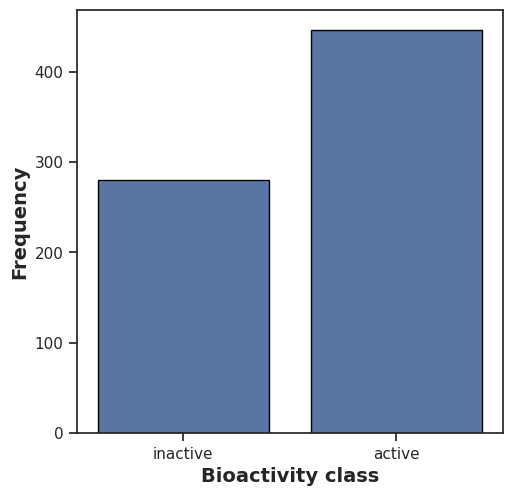

In [89]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='bioactivity_class', data=df_2class, edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_bioactivity_class.pdf')

### **Scatter plot of MW versus LogP**

It can be seen that the 2 bioactivity classes are spanning similar chemical spaces as evident by the scatter plot of MW vs LogP.

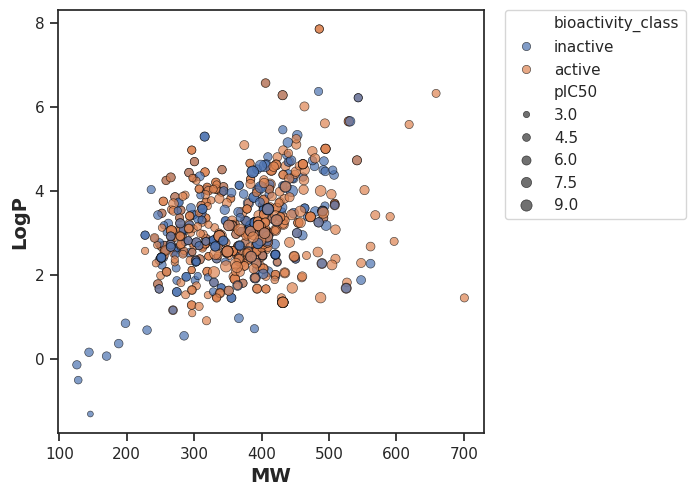

In [93]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_2class, hue='bioactivity_class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')

### **Box plots**

#### **pIC50 value**

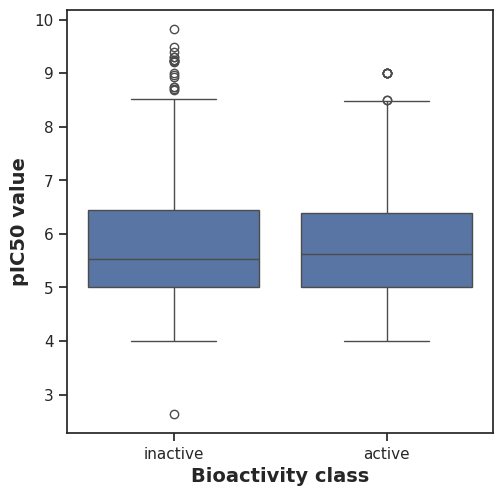

In [94]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'pIC50', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.savefig('plot_ic50.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [97]:
def mannwhitney(descriptor, verbose=False):
  # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/
  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'bioactivity_class'] # Changed 'class' to 'bioactivity_class'
  df = df_2class[selection]
  active = df[df['bioactivity_class'] == 'active'] # Changed 'class' to 'bioactivity_class'
  active = active[descriptor]

  selection = [descriptor, 'bioactivity_class'] # Changed 'class' to 'bioactivity_class'
  df = df_2class[selection]
  inactive = df[df['bioactivity_class'] == 'inactive'] # Changed 'class' to 'bioactivity_class'
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'

  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

In [100]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,63199.5,0.782515,0.05,Same distribution (fail to reject H0)


#### **MW**

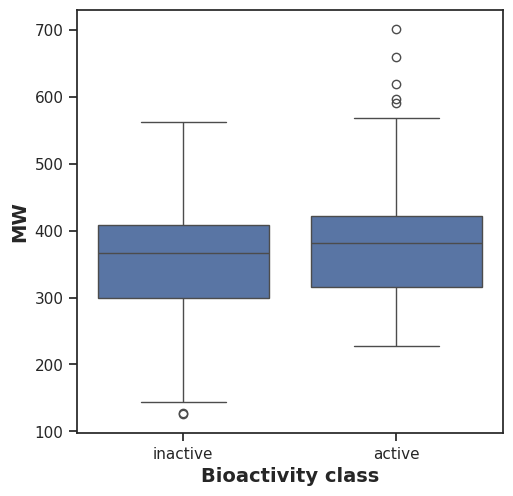

In [102]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'MW', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('plot_MW.pdf')

In [105]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,69222.0,0.013681,0.05,Different distribution (reject H0)


#### **LogP**

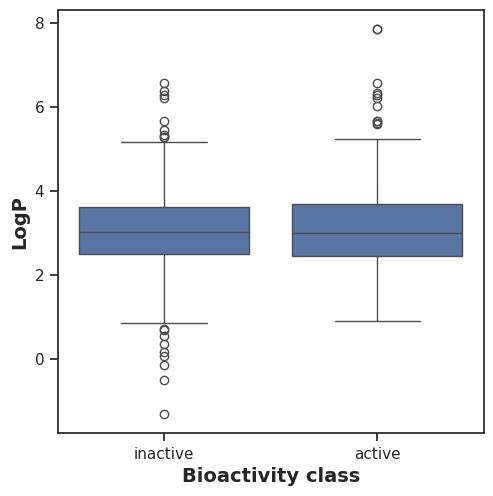

In [107]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'LogP', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('plot_LogP.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [110]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,61217.0,0.656711,0.05,Same distribution (fail to reject H0)


#### **NumHDonors**

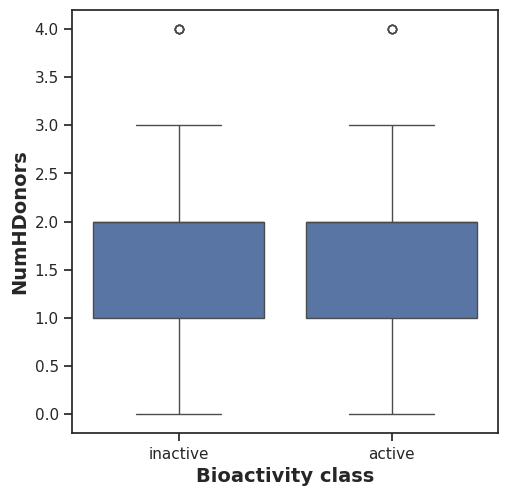

In [112]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHDonors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHDonors.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [115]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,67449.5,0.052503,0.05,Same distribution (fail to reject H0)


#### **NumHAcceptors**

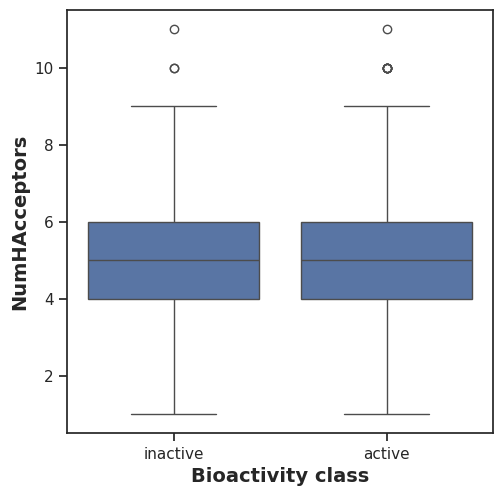

In [117]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHAcceptors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHAcceptors.pdf')

In [119]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,69035.0,0.015047,0.05,Different distribution (reject H0)


#### **Interpretation of Statistical Results**

##### **Box Plots**

###### **pIC50 values**

Taking a look at pIC50 values, the **actives** and **inactives** displayed ***statistically significant difference***, which is to be expected since threshold values (``IC50 < 1,000 nM = Actives while IC50 > 10,000 nM = Inactives``, corresponding to ``pIC50 > 6 = Actives and pIC50 < 5 = Inactives``) were used to define actives and inactives.

###### **Lipinski's descriptors**

All of the 4 Lipinski's descriptors exhibited ***statistically significant difference*** between the **actives** and **inactives**.

## **Zip files**

In [120]:
! zip -r results.zip . -i *.csv *.pdf

  adding: acetylcholinesterase_04_bioactivity_data_3class_pIC50.csv (deflated 79%)
  adding: mannwhitneyu_NumHAcceptors.csv (deflated 12%)
  adding: mannwhitneyu_NumHDonors.csv (deflated 10%)
  adding: plot_ic50.pdf (deflated 36%)
  adding: plot_MW.pdf (deflated 39%)
  adding: plot_bioactivity_class.pdf (deflated 39%)
  adding: bioactivity_data_preprocessed.csv (deflated 83%)
  adding: acetylcholinesterase_05_bioactivity_data_2class_pIC50.csv (deflated 79%)
  adding: plot_MW_vs_LogP.pdf (deflated 5%)
  adding: mannwhitneyu_pIC50.csv (deflated 10%)
  adding: mannwhitneyu_LogP.csv (deflated 7%)
  adding: plot_NumHDonors.pdf (deflated 39%)
  adding: plot_LogP.pdf (deflated 38%)
  adding: plot_NumHAcceptors.pdf (deflated 38%)
  adding: mannwhitneyu_MW.csv (deflated 8%)
